# Section 4: Visual Generation Suite
**High-Resolution Visualizations (6 Charts saved as PNGs)**

This notebook generates 6 distinct publication-ready figures for continuous telemetry distributions, subsystem fault counts, anomaly type donut proportions, sequence length box/violin plots, time-series ground-truth red shaded spans, and joint correlation plots.

In [1]:
import os
import sys
import glob
import ast
import re
import warnings
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

candidate_base_dirs = [
    'data', 'archive/data/data', 'archive/data', '.',
    '../data', '../archive/data/data', '../archive/data', '..'
]

test_dir = None
csv_path = None

for base in candidate_base_dirs:
    te = os.path.join(base, 'test')
    if os.path.exists(te) and len(glob.glob(os.path.join(te, '*.npy'))) > 0:
        test_dir = te
        break

for base in ['archive', 'data', '.', '../archive', '../data', '..']:
    cp = os.path.join(base, 'labeled_anomalies.csv')
    if os.path.exists(cp):
        csv_path = cp
        break

df_meta = pd.read_csv(csv_path)

def parse_sequences(val):
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except Exception:
            pass
    return val

def parse_classes(val):
    if isinstance(val, str):
        return re.findall(r'[a-zA-Z]+', val)
    return val

df_meta['anomaly_sequences'] = df_meta['anomaly_sequences'].apply(parse_sequences)
df_meta['class'] = df_meta['class'].apply(parse_classes)

def assign_subsystem(chan_id):
    prefix = chan_id.split('-')[0].upper()
    if prefix == 'P':
        return 'Power (P)'
    elif prefix in ['T', 'S']:
        return 'Thermal/Radiation (T/S)'
    elif prefix == 'E':
        return 'Actuators/Engines (E)'
    else:
        return 'Other Avionics (A/D/G/F)'

df_meta['subsystem'] = df_meta['chan_id'].apply(assign_subsystem)
df_meta['num_anomalies'] = df_meta['anomaly_sequences'].apply(len)
df_meta['total_anomaly_duration'] = df_meta['anomaly_sequences'].apply(
    lambda seqs: sum(end - start for start, end in seqs) if isinstance(seqs, list) else 0
)

smap_primary_vals = []
msl_primary_vals = []

for idx, row in df_meta.iterrows():
    chan_id = row['chan_id']
    spacecraft = row['spacecraft']
    test_path = os.path.join(test_dir, f"{chan_id}.npy")
    if not os.path.exists(test_path):
        continue
    arr = np.load(test_path)[:, 0]
    if spacecraft == 'SMAP':
        smap_primary_vals.append(arr)
    else:
        msl_primary_vals.append(arr)

smap_concat = np.concatenate(smap_primary_vals)
msl_concat = np.concatenate(msl_primary_vals)

def save_fig(filename):
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    parent = os.path.join("..", filename)
    plt.savefig(parent, dpi=300, bbox_inches='tight')
    print(f"Saved figure: {filename}")

Saved figure: fig1_telemetry_distributions.png


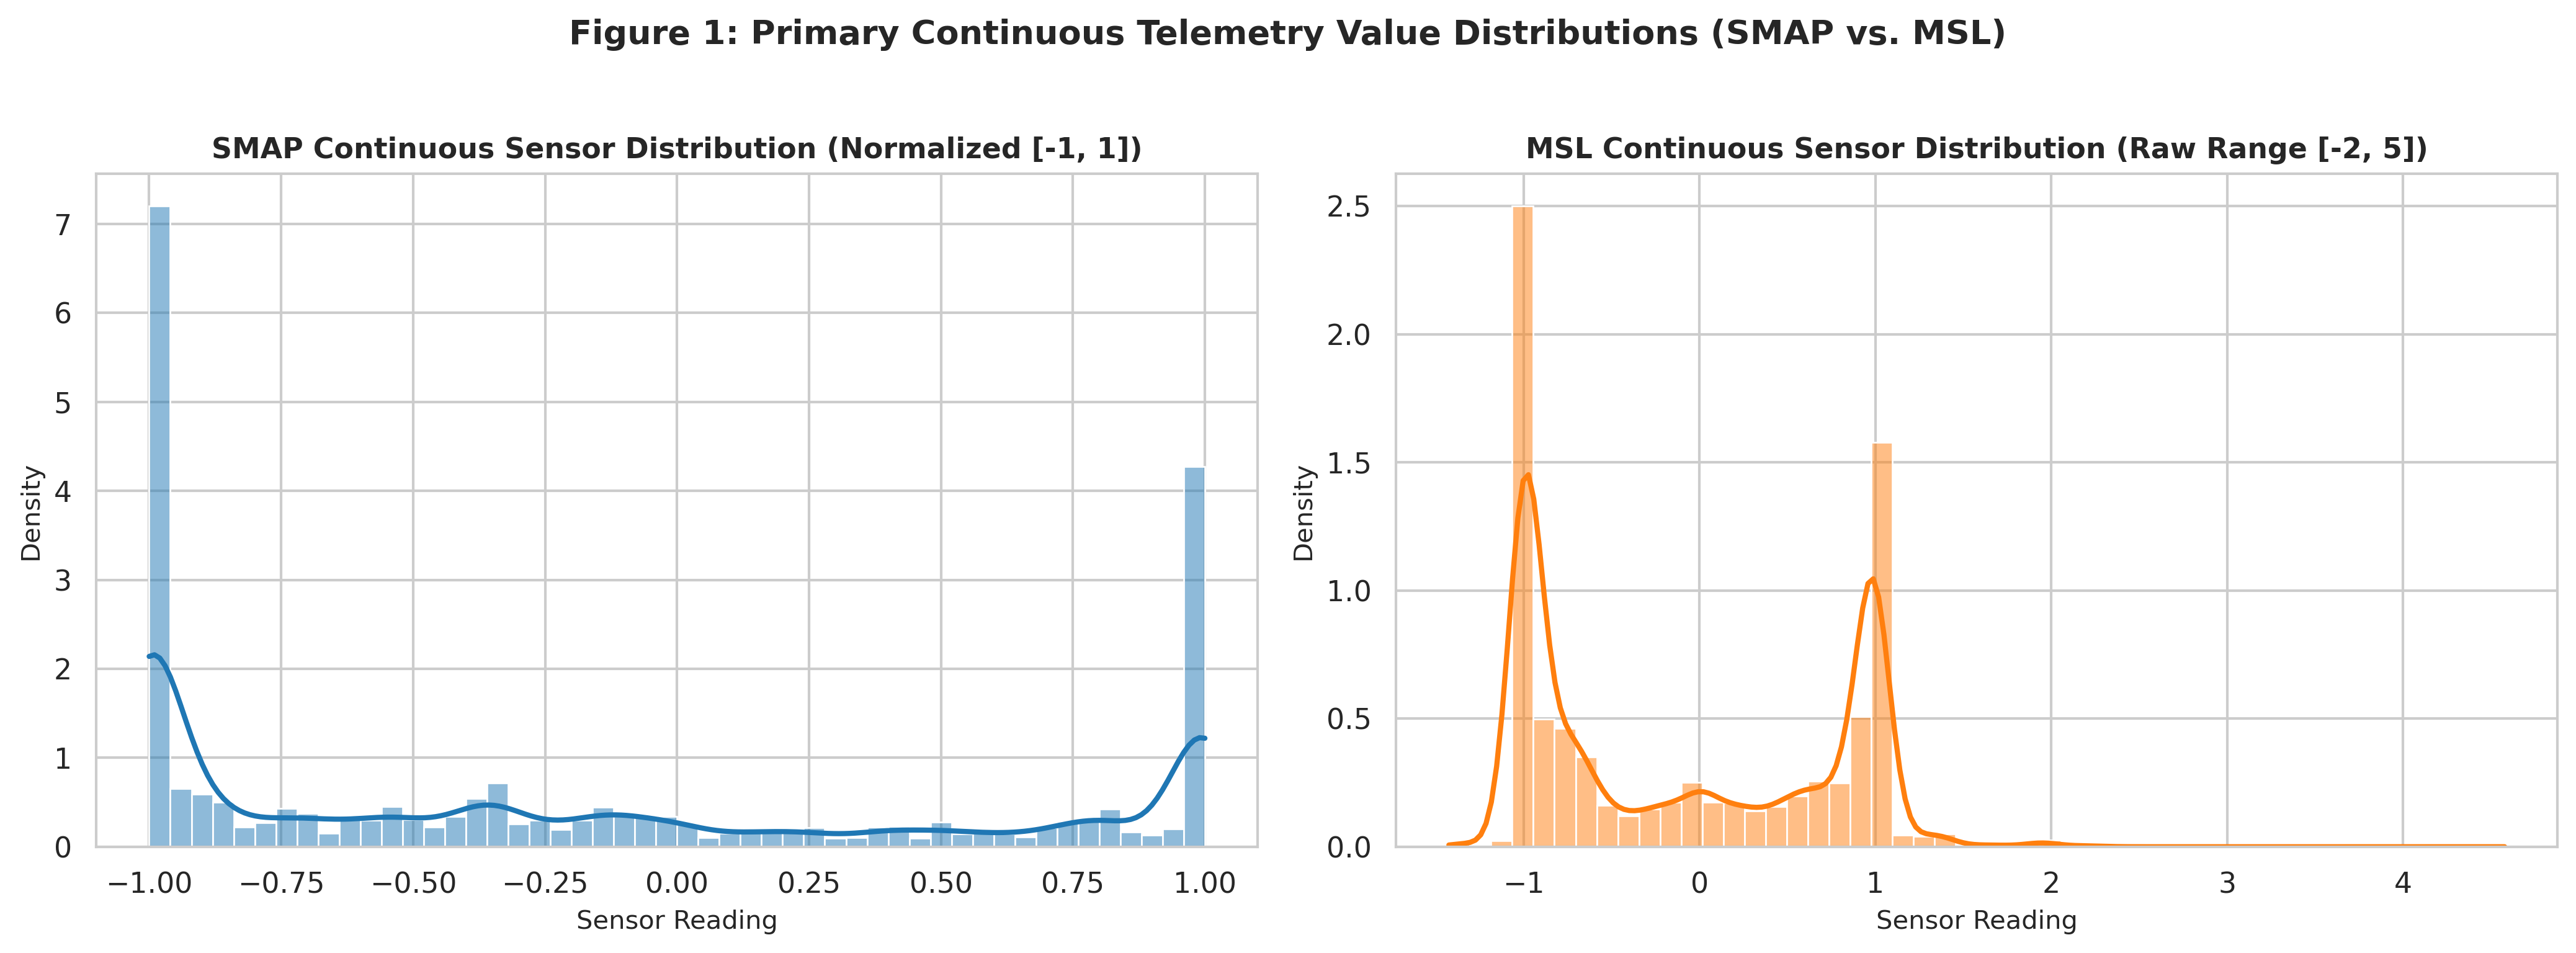

In [2]:
# --- Figure 1: Histogram & KDE ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(smap_concat, kde=True, ax=axes[0], color='#1f77b4', bins=50, stat="density", line_kws={'linewidth': 2})
axes[0].set_title("SMAP Continuous Sensor Distribution (Normalized [-1, 1])", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Sensor Reading", fontsize=10)
axes[0].set_ylabel("Density", fontsize=10)
axes[0].set_xlim(-1.1, 1.1)

msl_clipped = msl_concat[(msl_concat >= -2) & (msl_concat <= 5)]
sns.histplot(msl_clipped, kde=True, ax=axes[1], color='#ff7f0e', bins=50, stat="density", line_kws={'linewidth': 2})
axes[1].set_title("MSL Continuous Sensor Distribution (Raw Range [-2, 5])", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Sensor Reading", fontsize=10)
axes[1].set_ylabel("Density", fontsize=10)

plt.suptitle("Figure 1: Primary Continuous Telemetry Value Distributions (SMAP vs. MSL)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig("fig1_telemetry_distributions.png")
plt.show()

Saved figure: fig2_subsystem_anomaly_counts.png


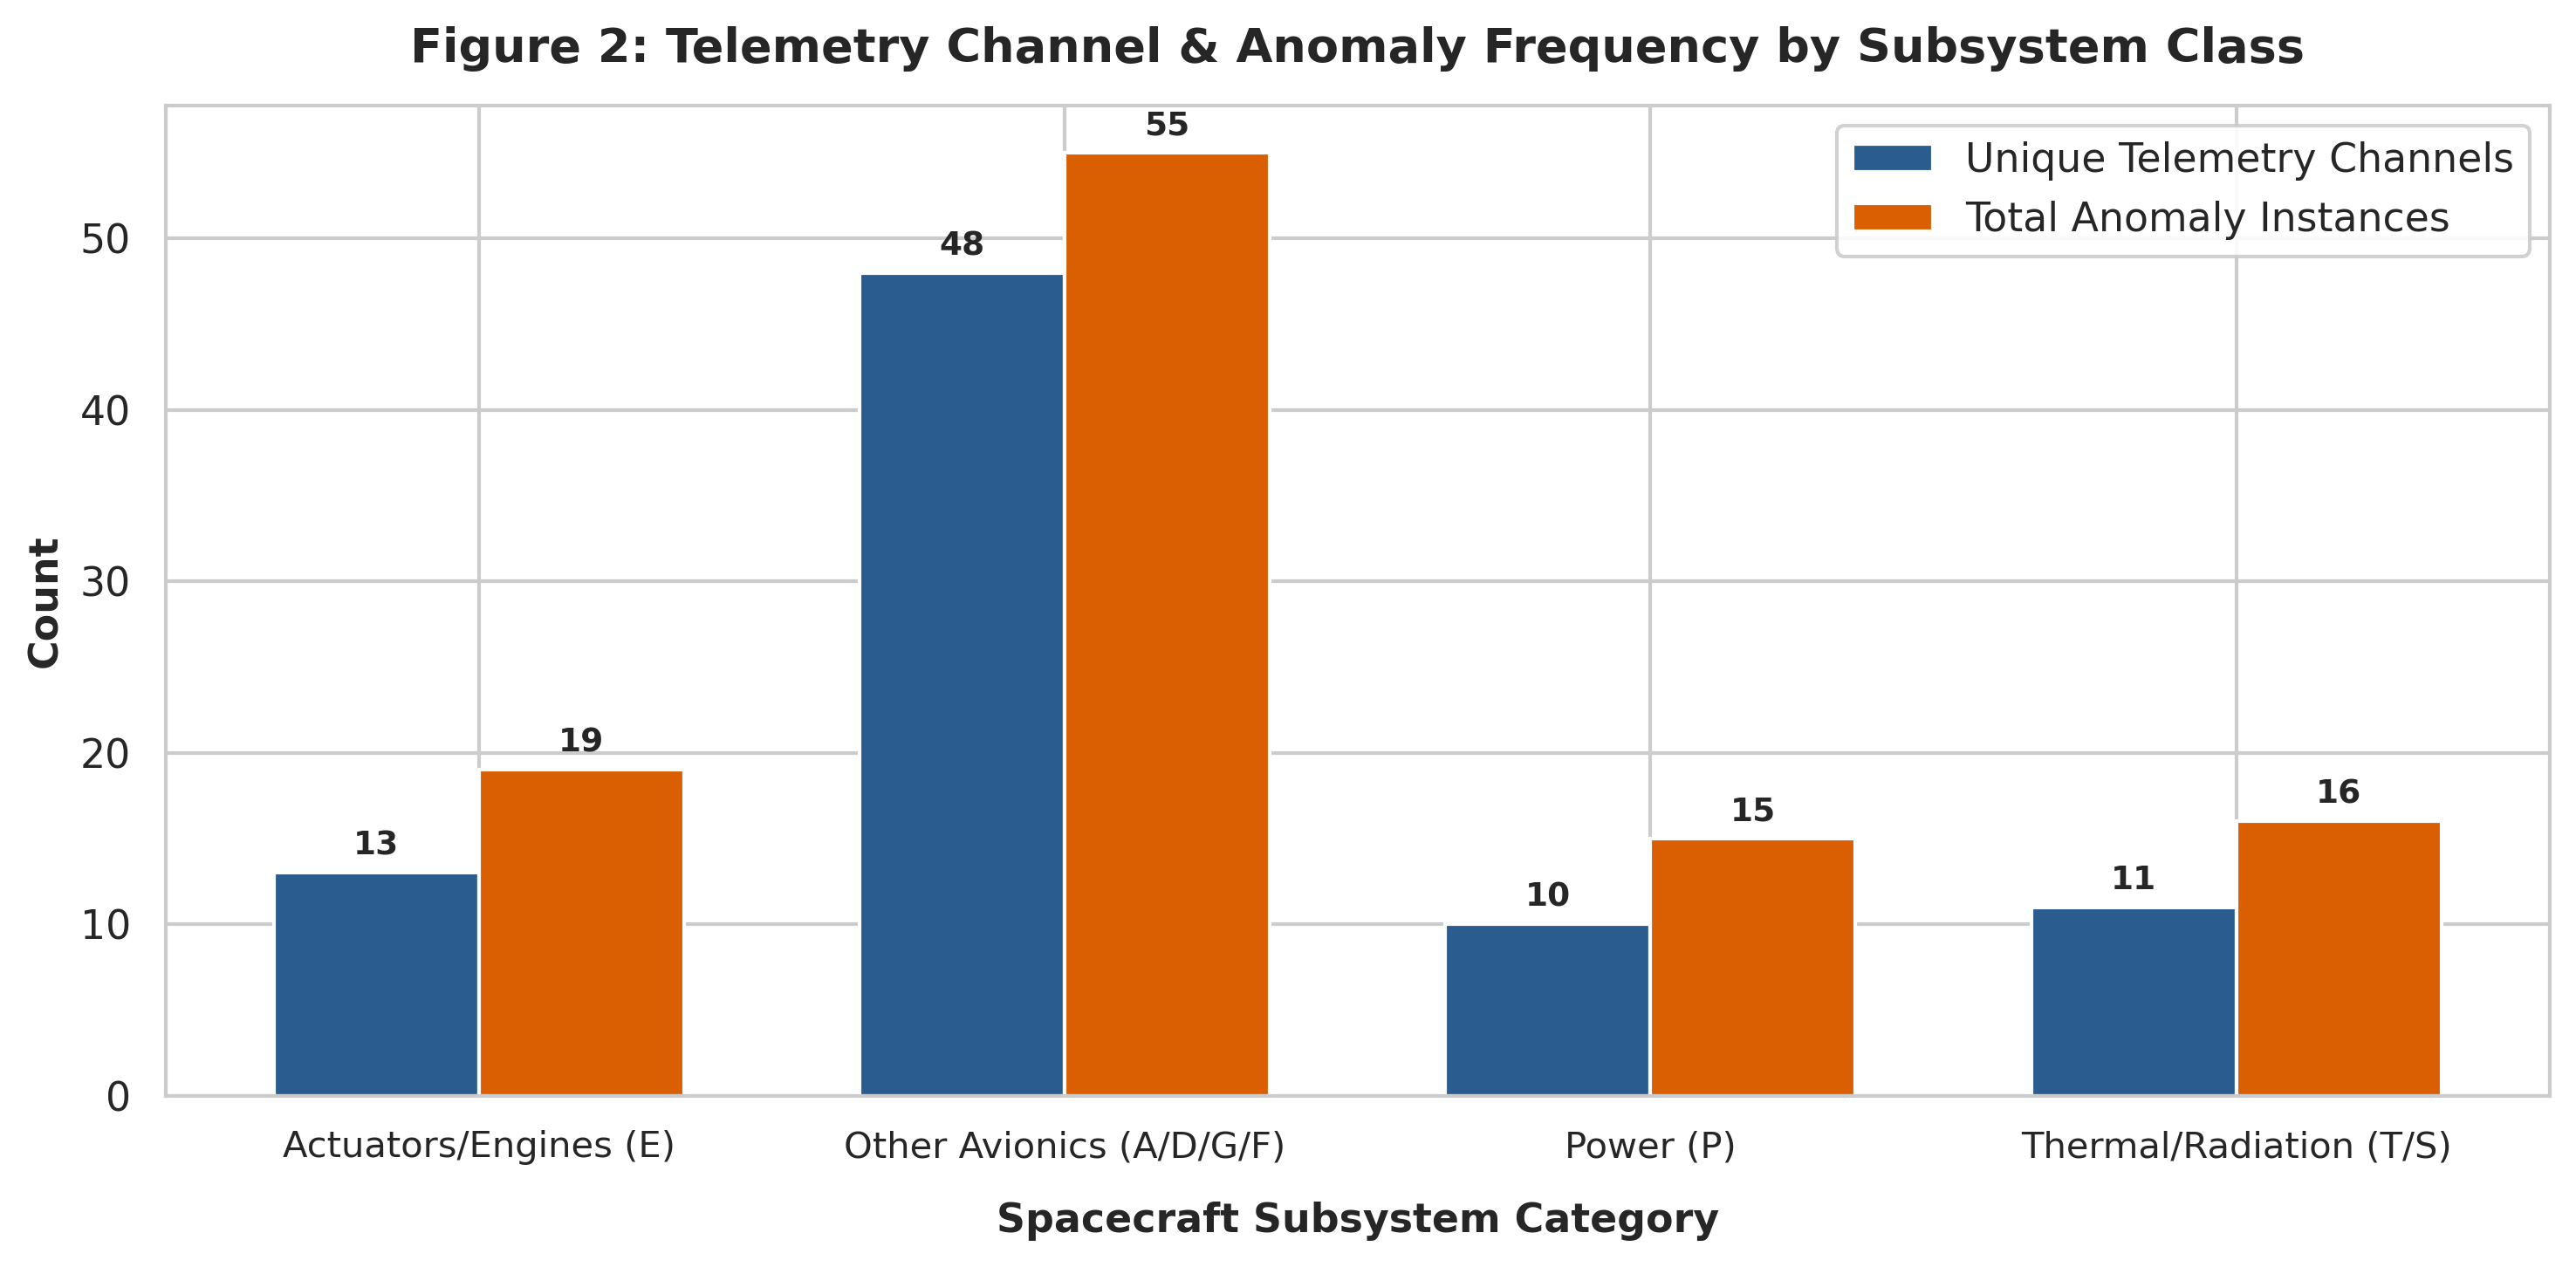

In [3]:
# --- Figure 2: Subsystem Bar Chart ---
subsys_summary = df_meta.groupby('subsystem').agg(
    channel_count=('chan_id', 'count'),
    total_anomalies=('num_anomalies', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
x = np.arange(len(subsys_summary))
width = 0.35

rects1 = ax1.bar(x - width/2, subsys_summary['channel_count'], width, label='Unique Telemetry Channels', color='#2b5c8f')
rects2 = ax1.bar(x + width/2, subsys_summary['total_anomalies'], width, label='Total Anomaly Instances', color='#d95f02')

ax1.set_xlabel('Spacecraft Subsystem Category', fontsize=11, fontweight='bold', labelpad=10)
ax1.set_ylabel('Count', fontsize=11, fontweight='bold')
ax1.set_title('Figure 2: Telemetry Channel & Anomaly Frequency by Subsystem Class', fontsize=13, fontweight='bold', pad=12)
ax1.set_xticks(x)
ax1.set_xticklabels(subsys_summary['subsystem'], fontsize=10)
ax1.legend(frameon=True, facecolor='white', framealpha=0.9)

for rect in rects1 + rects2:
    height = rect.get_height()
    ax1.annotate(f'{int(height)}', xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
save_fig("fig2_subsystem_anomaly_counts.png")
plt.show()

Saved figure: fig3_anomaly_type_donut.png


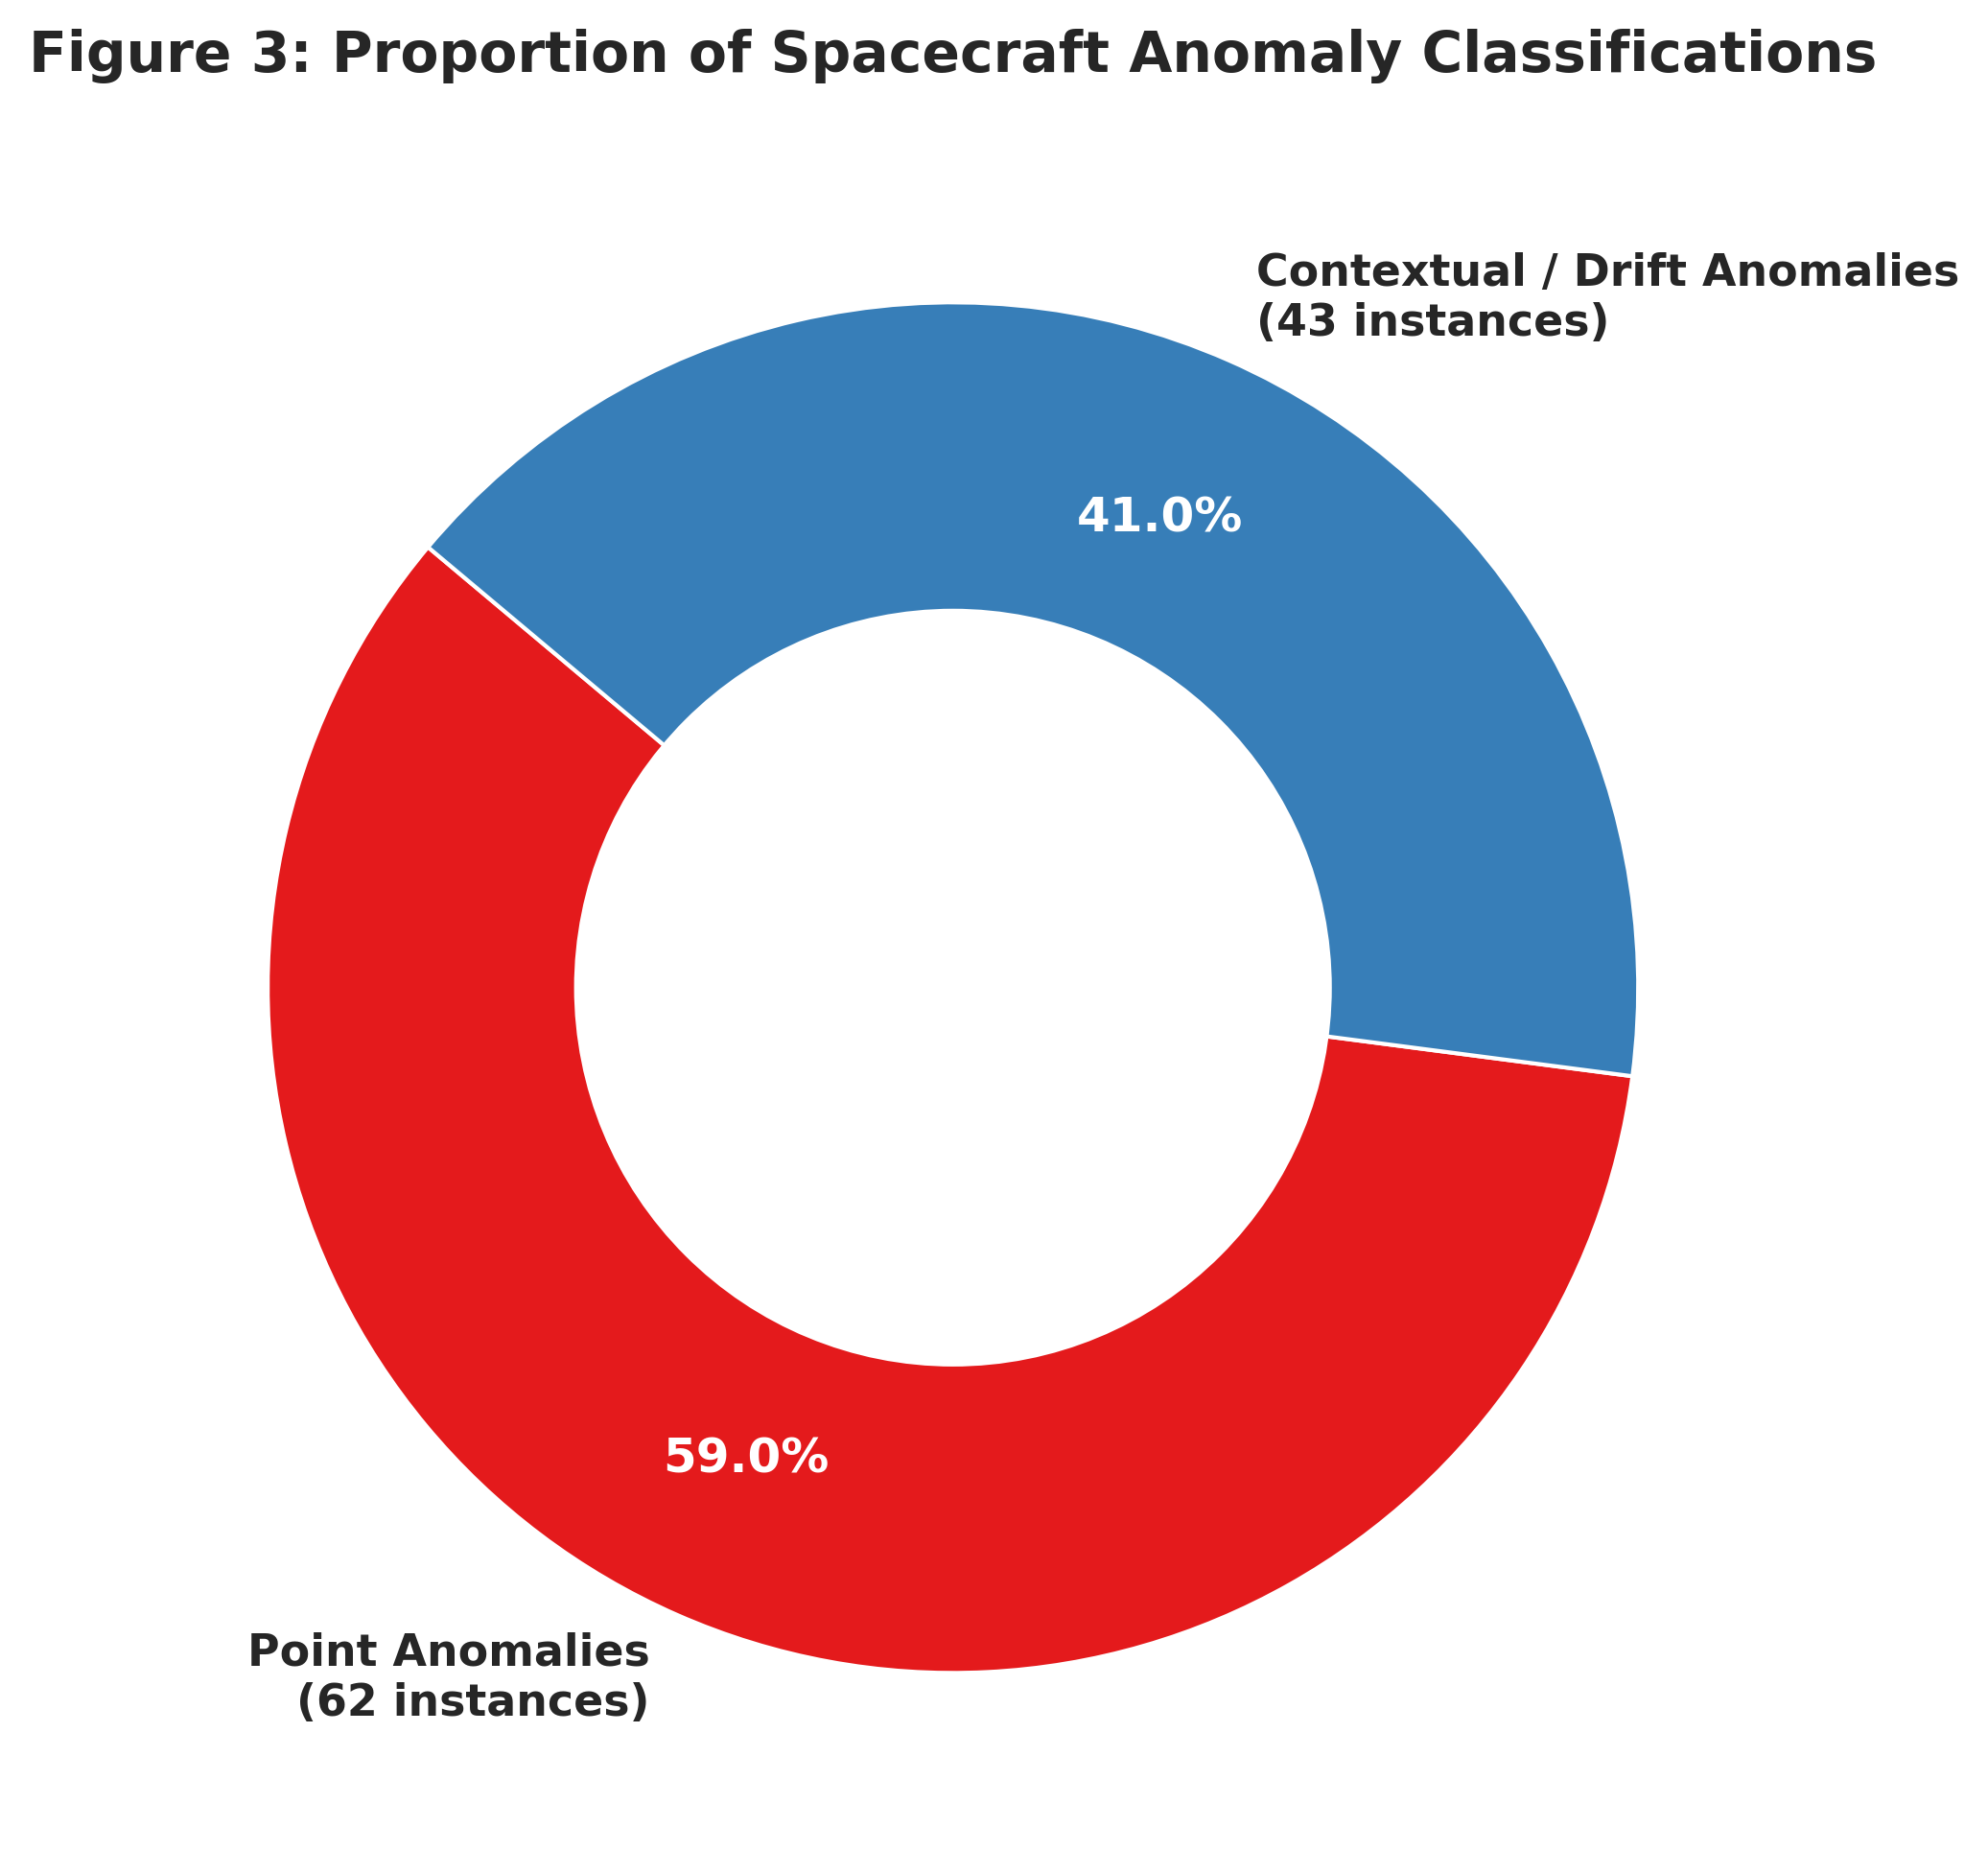

In [4]:
# --- Figure 3: Donut Chart ---
all_classes = [c for classes in df_meta['class'] for c in classes]
class_counts = pd.Series(all_classes).value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
colors = ['#e41a1c', '#377eb8']
labels = [f"Point Anomalies\n({class_counts.get('point', 0)} instances)", 
          f"Contextual / Drift Anomalies\n({class_counts.get('contextual', 0)} instances)"]

wedges, texts, autotexts = ax.pie(
    class_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors,
    pctdistance=0.75, textprops={'fontsize': 11, 'fontweight': 'bold'}
)
centre_circle = plt.Circle((0,0), 0.55, fc='white')
fig.gca().add_artist(centre_circle)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)

ax.set_title("Figure 3: Proportion of Spacecraft Anomaly Classifications", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
save_fig("fig3_anomaly_type_donut.png")
plt.show()

Saved figure: fig4_sequence_length_violin_box.png


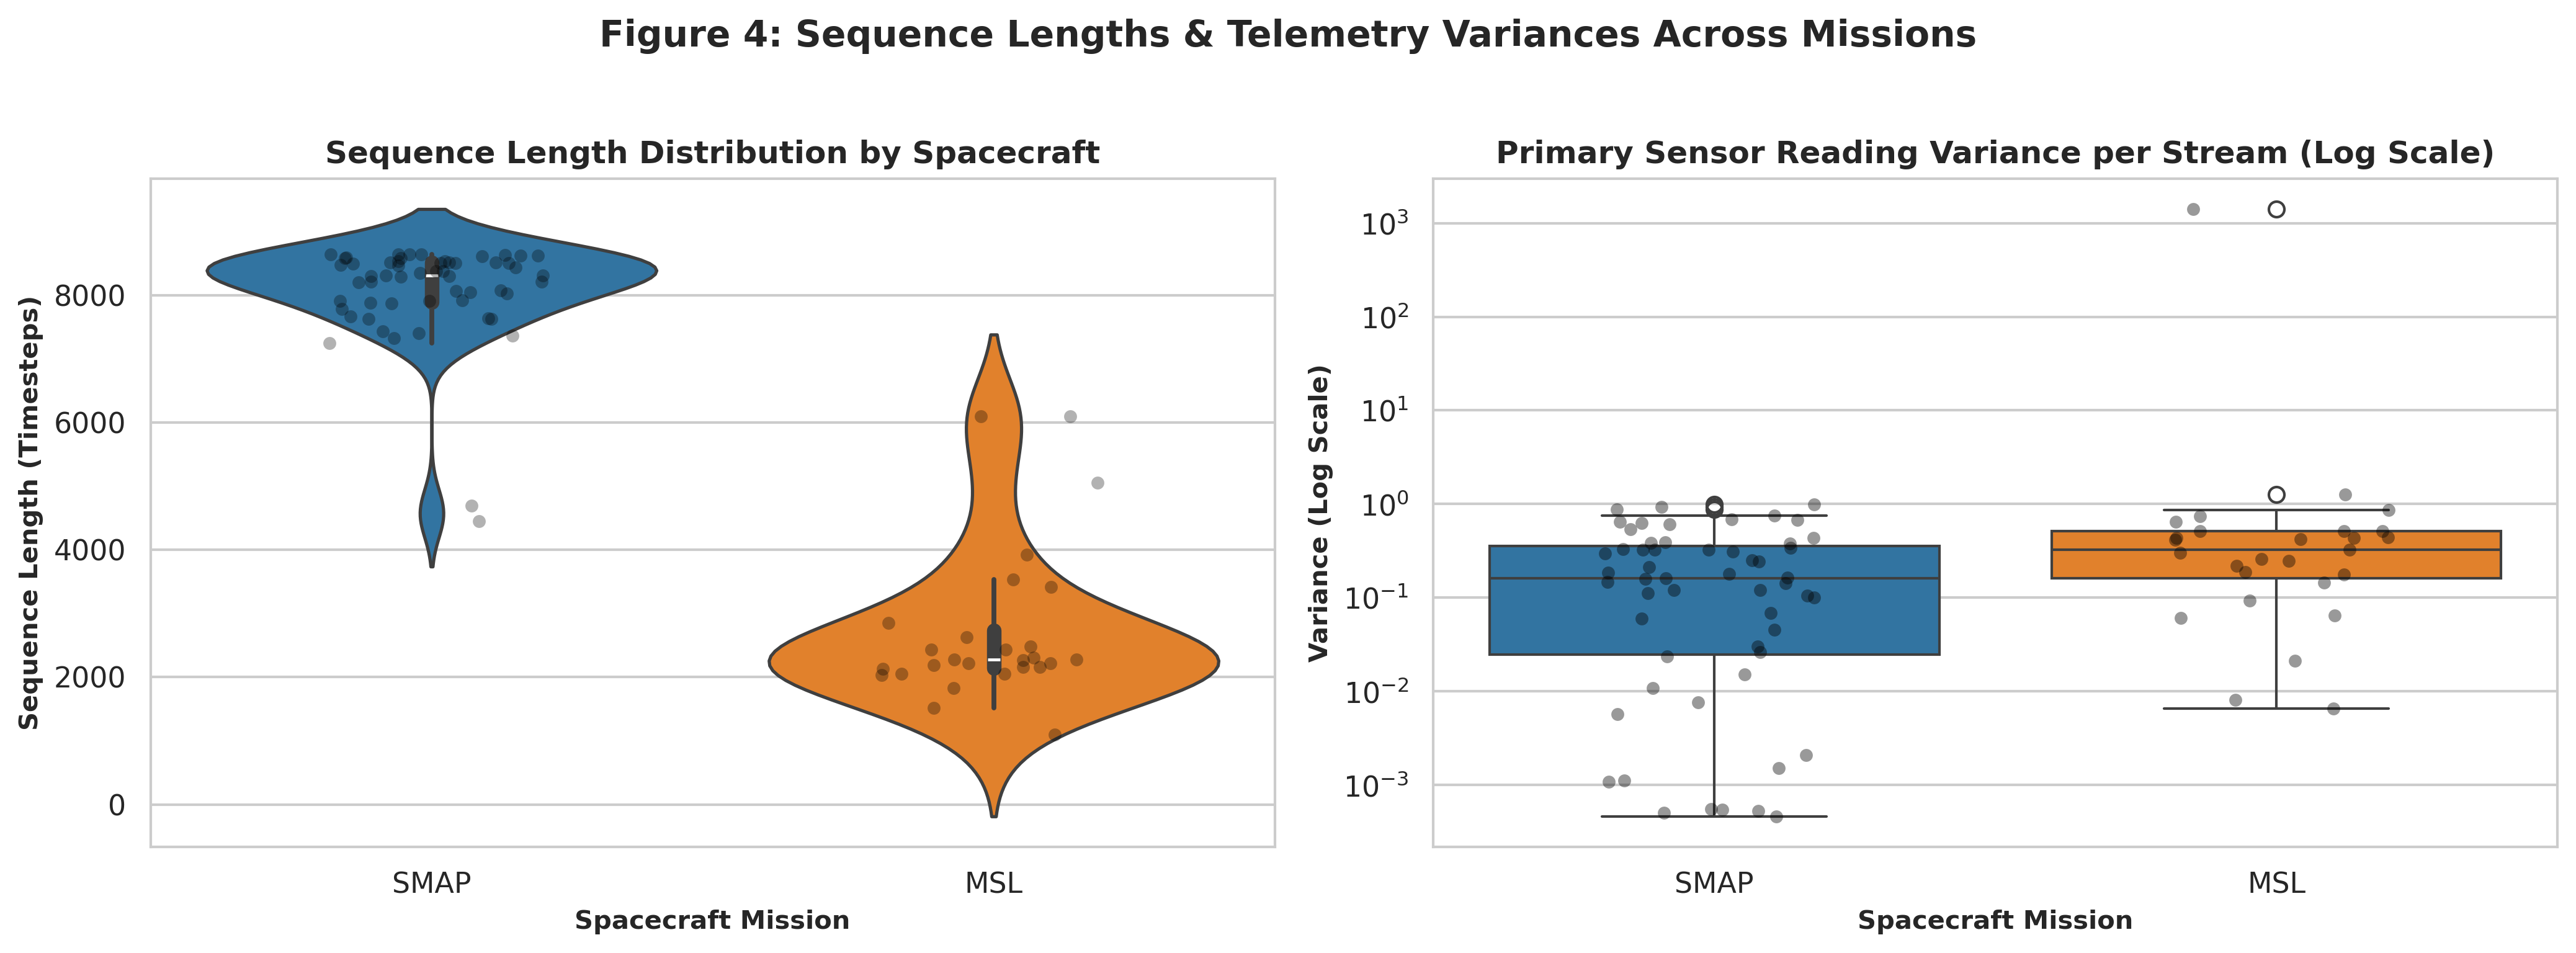

In [5]:
# --- Figure 4: Boxplot & Violin Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.violinplot(data=df_meta, x='spacecraft', y='num_values', ax=axes[0], palette=['#1f77b4', '#ff7f0e'], inner='box')
sns.stripplot(data=df_meta, x='spacecraft', y='num_values', ax=axes[0], color='black', alpha=0.3, jitter=0.2)
axes[0].set_title("Sequence Length Distribution by Spacecraft", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Spacecraft Mission", fontsize=10, fontweight='bold')
axes[0].set_ylabel("Sequence Length (Timesteps)", fontsize=10, fontweight='bold')

stream_vars = []
for idx, row in df_meta.iterrows():
    chan = row['chan_id']
    test_p = os.path.join(test_dir, f"{chan}.npy")
    if os.path.exists(test_p):
        v = np.var(np.load(test_p)[:, 0])
        stream_vars.append({'spacecraft': row['spacecraft'], 'variance': v})
df_vars = pd.DataFrame(stream_vars)

sns.boxplot(data=df_vars, x='spacecraft', y='variance', ax=axes[1], palette=['#1f77b4', '#ff7f0e'])
sns.stripplot(data=df_vars, x='spacecraft', y='variance', ax=axes[1], color='black', alpha=0.4, jitter=0.2)
axes[1].set_yscale('log')
axes[1].set_title("Primary Sensor Reading Variance per Stream (Log Scale)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Spacecraft Mission", fontsize=10, fontweight='bold')
axes[1].set_ylabel("Variance (Log Scale)", fontsize=10, fontweight='bold')

plt.suptitle("Figure 4: Sequence Lengths & Telemetry Variances Across Missions", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig("fig4_sequence_length_violin_box.png")
plt.show()

Saved figure: fig5_timeseries_ground_truth.png


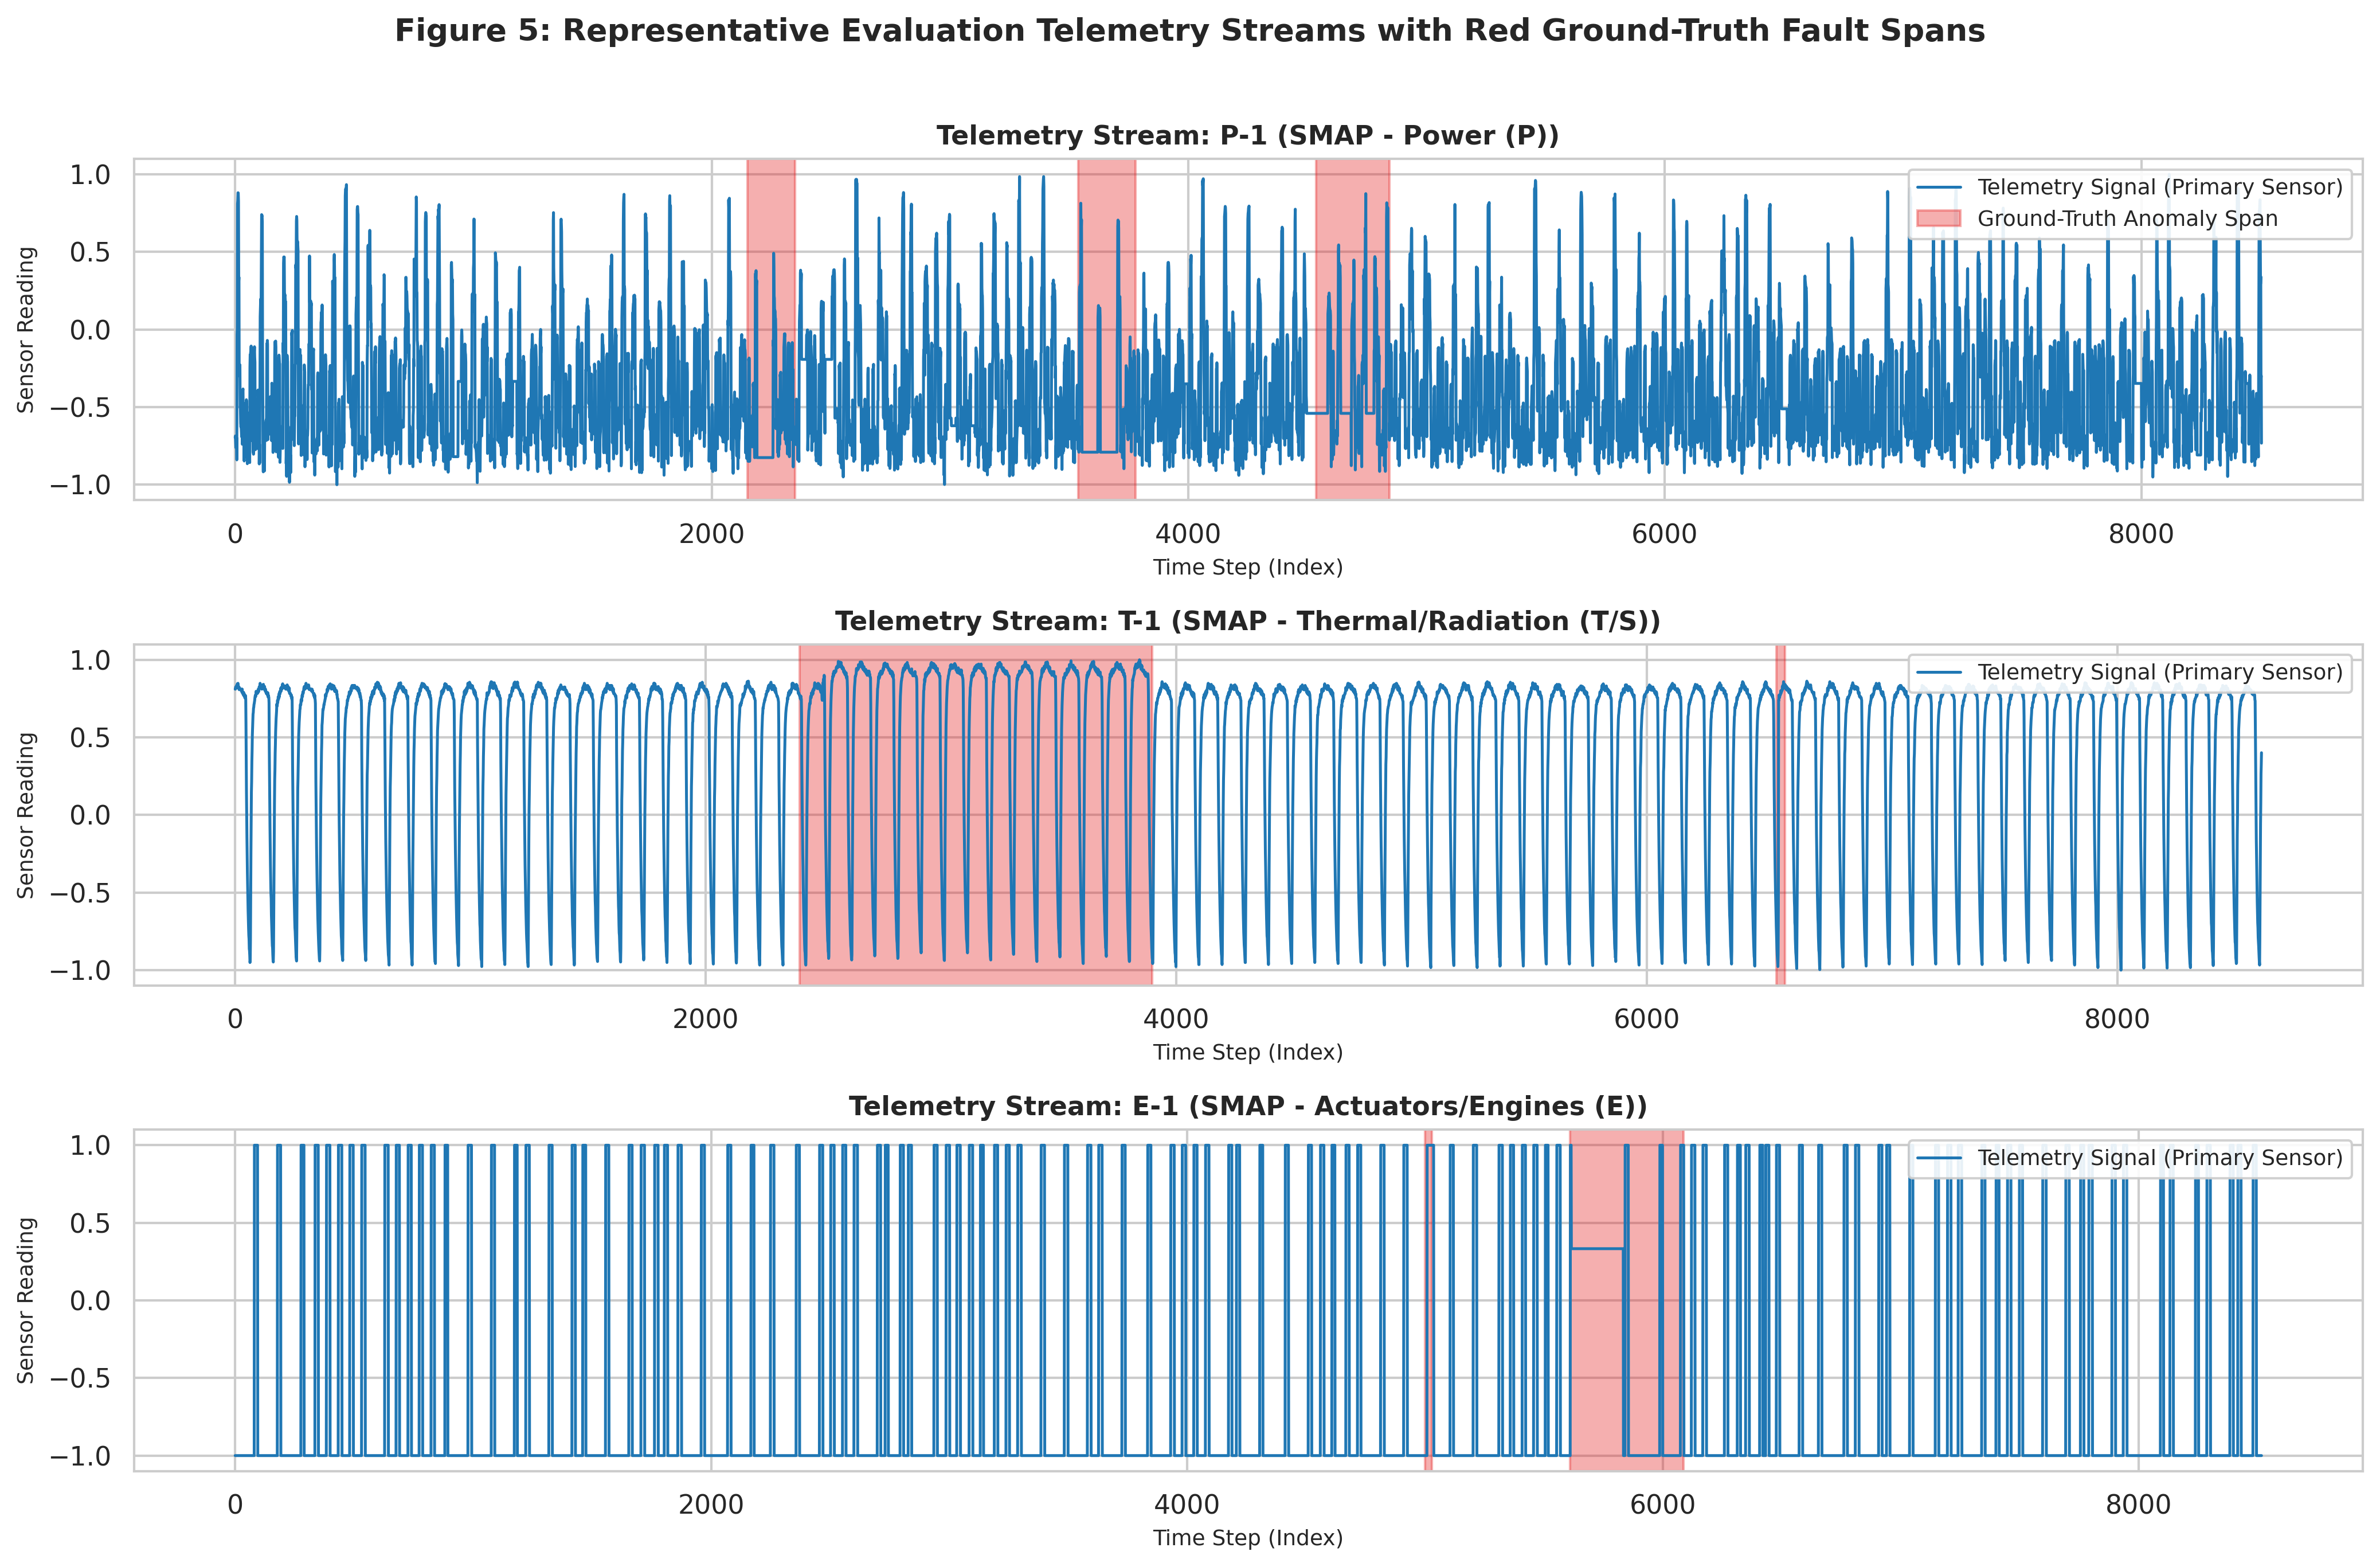

In [6]:
# --- Figure 5: Multi-Panel Time Series with Red Ground-Truth Spans ---
sample_chans = ['P-1', 'T-1', 'E-1']
valid_chans = [c for c in sample_chans if c in df_meta['chan_id'].values]

if len(valid_chans) < 3:
    valid_chans = df_meta['chan_id'].head(3).tolist()

fig, axes = plt.subplots(len(valid_chans), 1, figsize=(14, 3 * len(valid_chans)), sharex=False)
if len(valid_chans) == 1:
    axes = [axes]

for i, chan_id in enumerate(valid_chans):
    row = df_meta[df_meta['chan_id'] == chan_id].iloc[0]
    test_p = os.path.join(test_dir, f"{chan_id}.npy")
    arr = np.load(test_p)[:, 0]
    seqs = row['anomaly_sequences']
    spacecraft = row['spacecraft']

    axes[i].plot(arr, color='#1f77b4', linewidth=1.2, label='Telemetry Signal (Primary Sensor)')

    if isinstance(seqs, list):
        for j, (start, end) in enumerate(seqs):
            lbl = 'Ground-Truth Anomaly Span' if (i == 0 and j == 0) else None
            axes[i].axvspan(start, end, color='#e41a1c', alpha=0.35, label=lbl)

    axes[i].set_title(f"Telemetry Stream: {chan_id} ({spacecraft} - {row['subsystem']})", fontsize=11, fontweight='bold')
    axes[i].set_ylabel("Sensor Reading", fontsize=9)
    axes[i].set_xlabel("Time Step (Index)", fontsize=9)
    axes[i].legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, fontsize=9)

plt.suptitle("Figure 5: Representative Evaluation Telemetry Streams with Red Ground-Truth Fault Spans", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig("fig5_timeseries_ground_truth.png")
plt.show()

Saved figure: fig6_length_vs_duration_jointplot.png


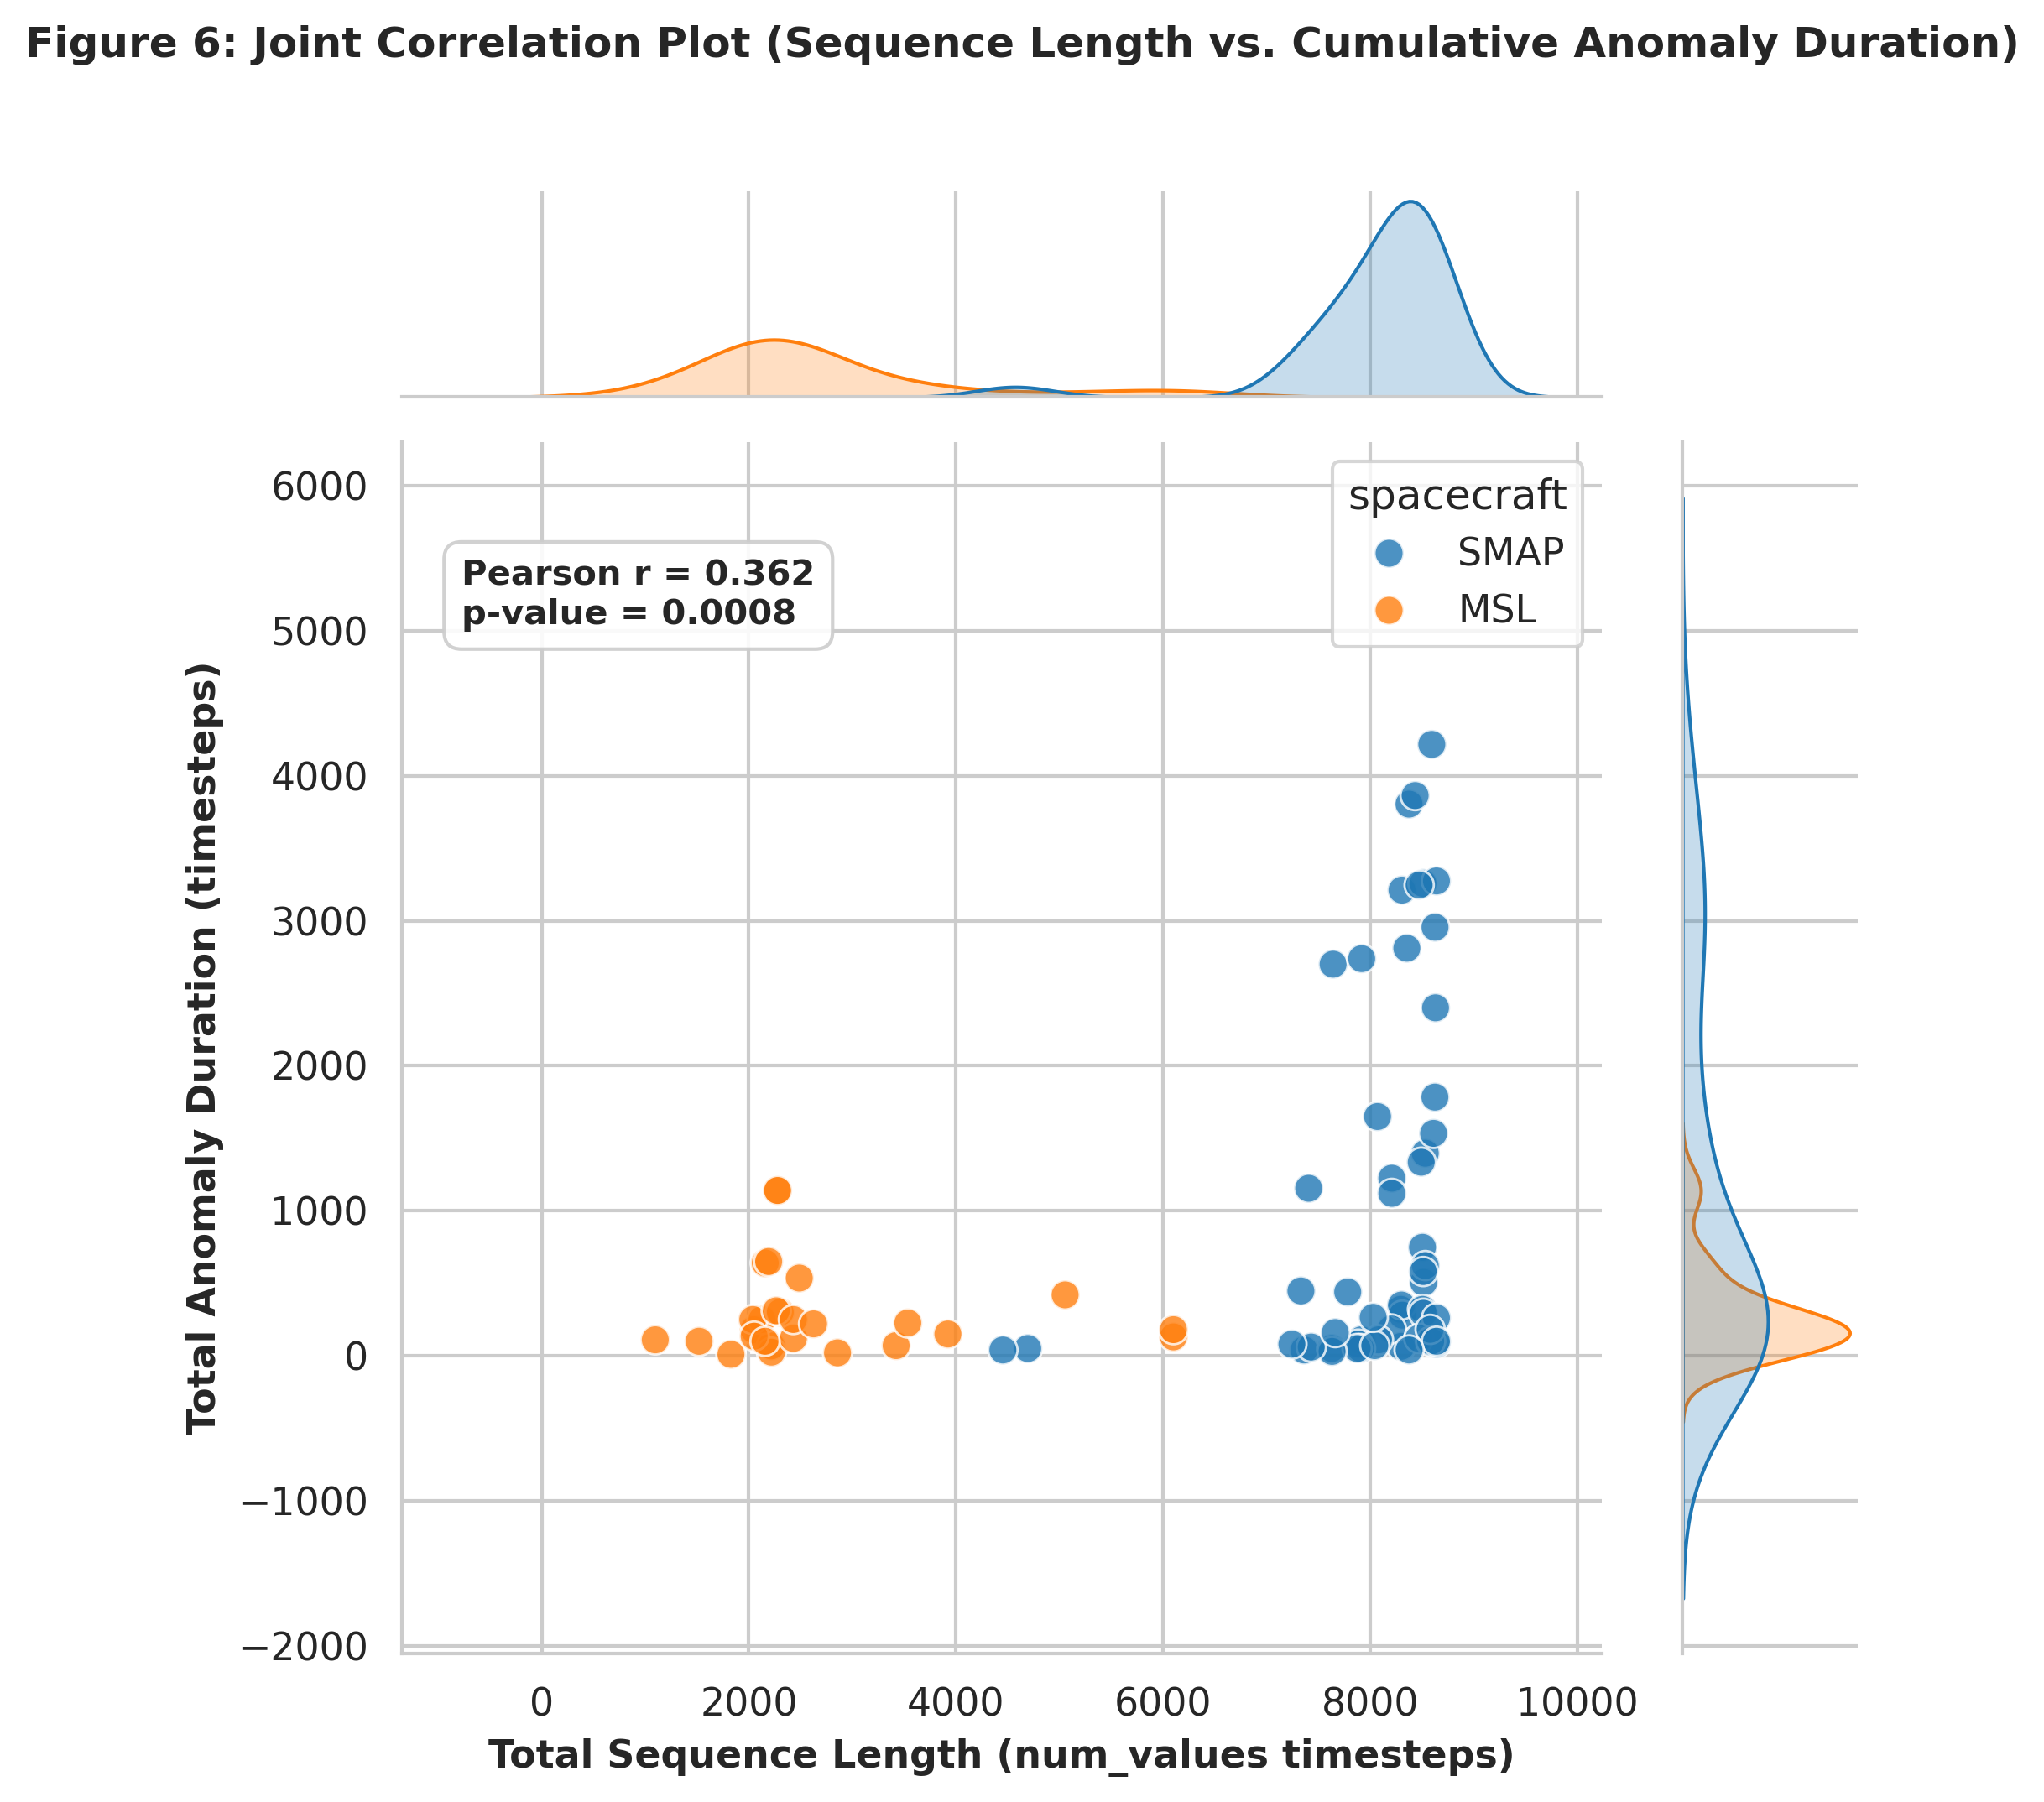

In [7]:
# --- Figure 6: Joint Plot ---
joint_plot = sns.jointplot(
    data=df_meta, x='num_values', y='total_anomaly_duration', hue='spacecraft',
    palette=['#1f77b4', '#ff7f0e'], kind='scatter', height=7, s=70, alpha=0.8
)
joint_plot.ax_joint.set_xlabel("Total Sequence Length (num_values timesteps)", fontsize=11, fontweight='bold')
joint_plot.ax_joint.set_ylabel("Total Anomaly Duration (timesteps)", fontsize=11, fontweight='bold')

corr_coef, p_val = stats.pearsonr(df_meta['num_values'], df_meta['total_anomaly_duration'])
joint_plot.ax_joint.annotate(
    f"Pearson r = {corr_coef:.3f}\np-value = {p_val:.4f}",
    xy=(0.05, 0.85), xycoords='axes fraction',
    bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='#cccccc', alpha=0.9),
    fontsize=10, fontweight='bold'
)

plt.suptitle("Figure 6: Joint Correlation Plot (Sequence Length vs. Cumulative Anomaly Duration)", fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig("fig6_length_vs_duration_jointplot.png")
plt.show()